In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["font.family"] = [
    "Arial Unicode MS",
    "Heiti TC",
    "Hiragino Sans GB",
]  # macOS中文字体
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

results_dir = "results/"
llm_result = [f for f in os.listdir(results_dir) if f.lower().endswith(".csv")]
llms = [f.split('.')[0] for f in llm_result]
colors = ["#5867AF", "#F6944B", "#5C3C0D", "#304E7E"]
llms

['qwen', 'chatglm', 'kimi', 'deepseek']

In [16]:
def plot_results(y="ReturnPercent"):
    plt.figure(figsize=(12, 6))

    for i, file_name in enumerate(llm_result):
        try:
            file_path = os.path.join(results_dir, file_name)
            df = pd.read_csv(file_path)
            df["Date"] = pd.to_datetime(df["Date"])

            plt.plot(
                df["Date"],
                df[y],
                color=colors[i],
                linewidth=2,
                label=llms[i],
            )

        except Exception as e:
            print(f"处理文件 {file_path} 时出错: {e}")

    plt.title("Trading results of LLMs", fontsize=14, fontweight="bold")
    plt.ylabel(y, fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

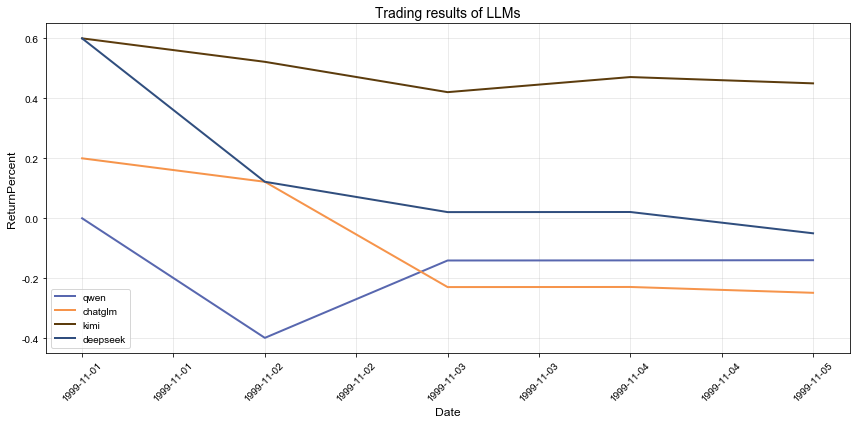

In [17]:
plot_results(y="ReturnPercent")

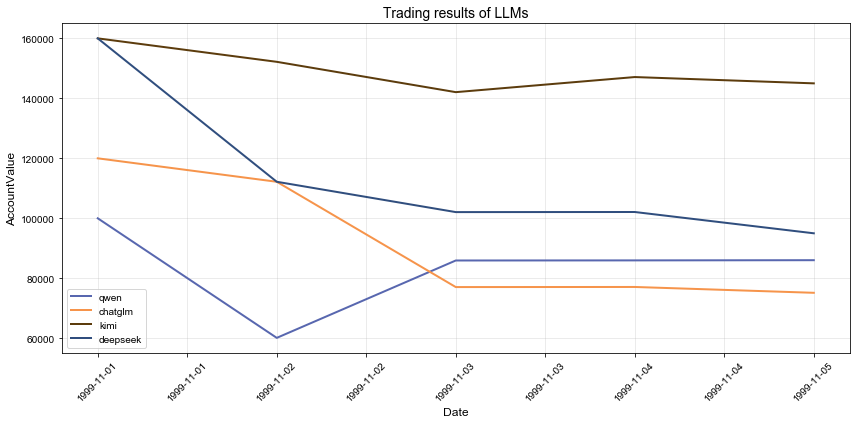

In [18]:
plot_results(y="AccountValue")